In [5]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('dogs-vs-cats')

print("Path to competition files:", path)

100%|██████████| 812M/812M [00:08<00:00, 104MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/dogs-vs-cats


In [6]:
import os

path = "/root/.cache/kagglehub/competitions/dogs-vs-cats"

print(os.listdir(path))

['sampleSubmission.csv', 'train.zip', 'test1.zip']


In [7]:
import zipfile
import os

train_zip = "/root/.cache/kagglehub/competitions/dogs-vs-cats/train.zip"

with zipfile.ZipFile(train_zip, 'r') as zip_ref:
    zip_ref.extractall("/content/train_data")

print("Training data extracted!")

Training data extracted!


In [30]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [8]:
import os

train_dir = "/content/train_data/train"

print("Number of images:", len(os.listdir(train_dir)))

Number of images: 25000


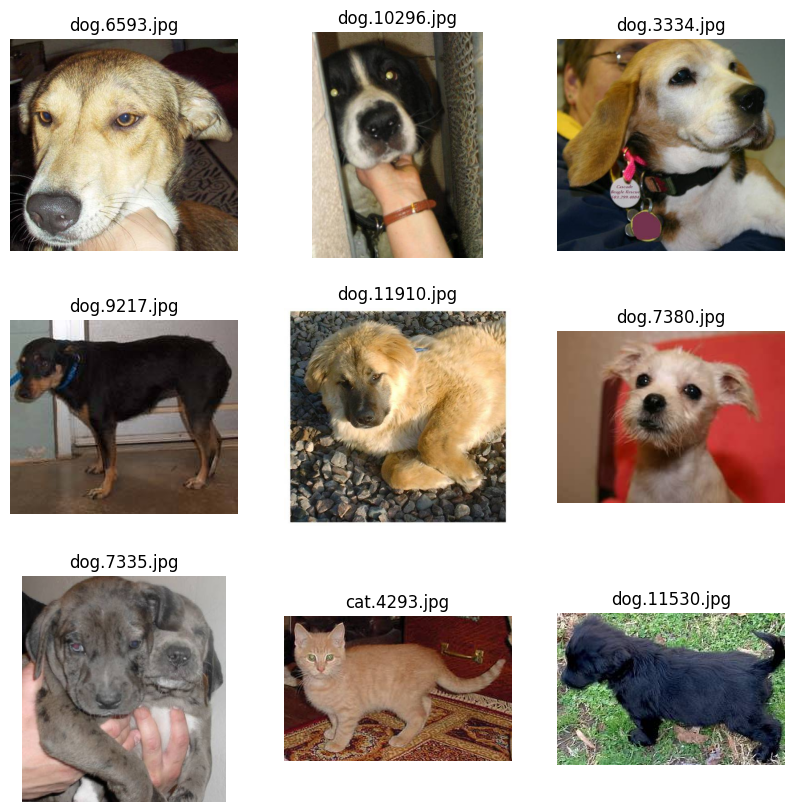

In [9]:
import cv2
import matplotlib.pyplot as plt
import os

files = os.listdir(train_dir)[:9]

plt.figure(figsize=(10,10))

for i, file in enumerate(files):
    img = cv2.imread(os.path.join(train_dir, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(file)
    plt.axis("off")

plt.show()

In [31]:
IMG_SIZE = 64

features = []
labels = []

MAX_CATS = 2000
MAX_DOGS = 2000

cat_count = 0
dog_count = 0

files = os.listdir(train_dir)

for file in files:

    if file.startswith("cat") and cat_count < MAX_CATS:

        img = cv2.imread(os.path.join(train_dir, file))

        if img is not None:

            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            hog_feature = hog(
                img,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                block_norm='L2-Hys'
            )

            features.append(hog_feature)
            labels.append(0)

            cat_count += 1

    elif file.startswith("dog") and dog_count < MAX_DOGS:

        img = cv2.imread(os.path.join(train_dir, file))

        if img is not None:

            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            hog_feature = hog(
                img,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                block_norm='L2-Hys'
            )

            features.append(hog_feature)
            labels.append(1)

            dog_count += 1

    if cat_count >= MAX_CATS and dog_count >= MAX_DOGS:
        break

print("Cats:", cat_count)
print("Dogs:", dog_count)

Cats: 2000
Dogs: 2000


In [32]:
X = np.array(features)
y = np.array(labels)

print(X.shape)
print(y.shape)

(4000, 1764)
(4000,)


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    random_state=42
)

svm.fit(X_train, y_train)

SVC(C=10, random_state=42)

In [36]:
svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    random_state=42
)

svm.fit(X_train, y_train)

SVC(C=10, random_state=42)

In [37]:
y_pred = svm.predict(X_test)

In [38]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.71


In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.74      0.72       400
           1       0.72      0.68      0.70       400

    accuracy                           0.71       800
   macro avg       0.71      0.71      0.71       800
weighted avg       0.71      0.71      0.71       800



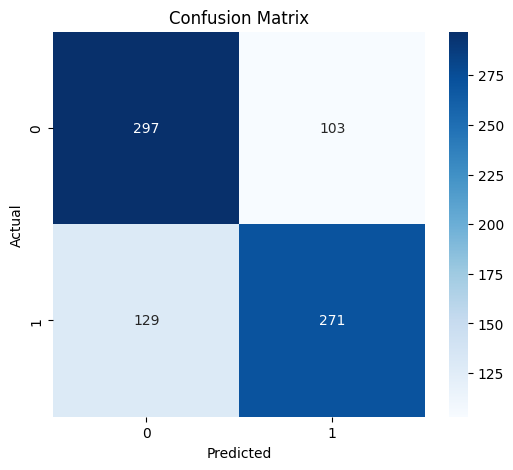

In [40]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

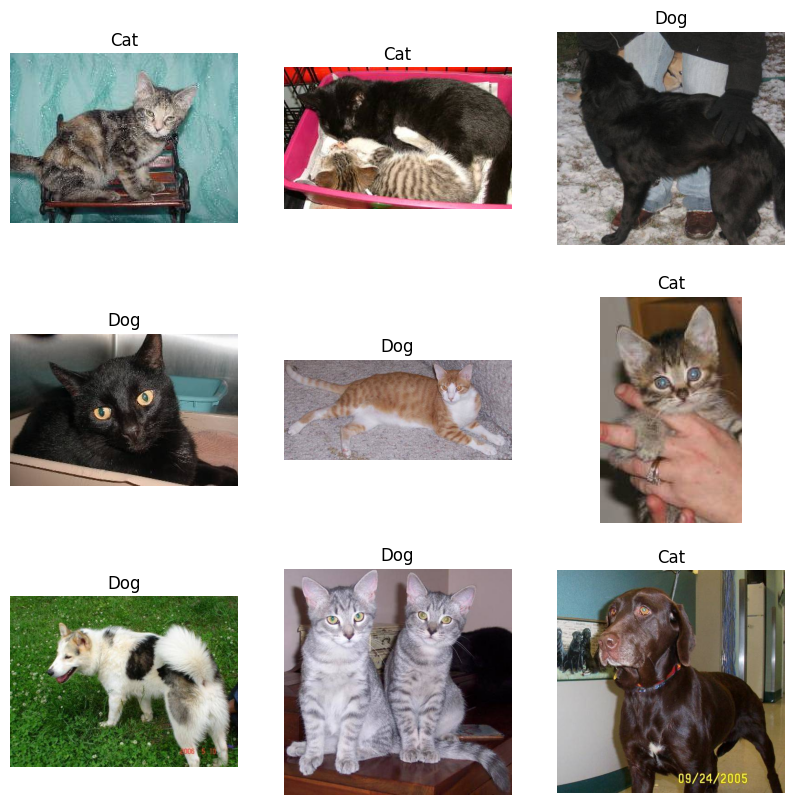

In [41]:
indices = np.random.choice(len(X_test), 9, replace=False)

plt.figure(figsize=(10,10))

for i, idx in enumerate(indices):

    image_file = files[idx]

    img = cv2.imread(os.path.join(train_dir, image_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    pred = y_pred[idx]

    label = "Dog" if pred == 1 else "Cat"

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.show()